In [1]:
from Parts.imports import *
from Parts.data_loader import DatasetLoader, DatasetLoaderV2
from Parts.models import U_NET_VANILLA, U_NET_RESNET, U_NET_RESNET_ATTENTION, U_NET_PLUS_PLUS, TRANS_U_NET
from Parts.training_loop import TrainingLoop, TrainingLoopAdvanced, SaveState, EarlyStopping
from Parts.losses import DiceLoss, Mixed_Dice_Sigmoid

DEBUG = False

In [2]:
model = U_NET_RESNET_ATTENTION()
optm = torch.optim.Adam(model.parameters())
loss = DiceLoss()

In [3]:
'''
model_states = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optm.state_dict(),
            'loss_history_epoch' : trainer.loss_history_epoch,
            'batch_loss' : trainer.batch_loss
        }
'''

"\nmodel_states = {\n            'model_state_dict': model.state_dict(),\n            'optimizer_state_dict': optm.state_dict(),\n            'loss_history_epoch' : trainer.loss_history_epoch,\n            'batch_loss' : trainer.batch_loss\n        }\n"

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
device

'cpu'

In [6]:
checkpoint = torch.load(f=r"C:\Users\itizs\Downloads\U_NET_ATTENTION.torch", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

U_NET_RESNET_ATTENTION(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [7]:
data_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\images"
label_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\masks"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


pred :: -17.614667892456055 9.351798057556152


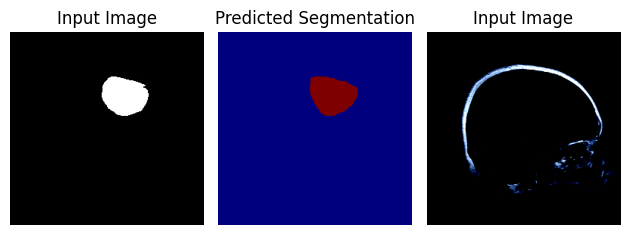

In [13]:
data_loader = DatasetLoaderV2(data_dir=data_test, label_dir=label_test, dim=(256, 256))
dataz =  DataLoader(data_loader, 1, 1)

for data, label in dataz:
    data = data.to(device)

    prediction = model(data)
    print(f"pred :: {prediction.min()} {prediction.max()}")
    prediction = torch.sigmoid(prediction)
    # prediction = (prediction > 0.5).float()
    final_mask = prediction.cpu().detach().numpy()
    final_mask = (final_mask > 0.5)
    fig, axes = plt.subplots(1, 3)

    axes[0].imshow(label.squeeze(), cmap='gray')
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(final_mask.squeeze(), cmap='jet')
    axes[1].set_title("Predicted Segmentation")
    axes[1].axis('off')

    axes[2].imshow(data.detach().cpu().squeeze().numpy().transpose(1, 2, 0))
    axes[2].set_title("Input Image")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    break

In [17]:
resnet_att = torch.load(r"c:\Users\itizs\Downloads\U_NET_ATTENTION.torch", torch.device('cpu'))
resnet = torch.load(r"c:\Users\itizs\Downloads\U_NET_RESNET.torch", torch.device('cpu'))
u_net = torch.load(r"c:\Users\itizs\Downloads\U_NET(3).torch", torch.device('cpu'))

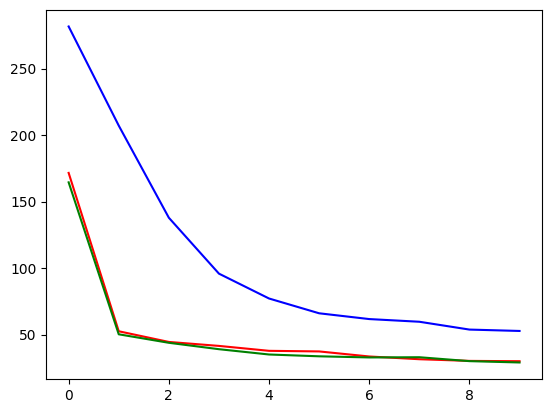

In [18]:
plt.plot(resnet_att['loss_history_epoch'], color = 'red')
plt.plot(resnet['loss_history_epoch'], color = 'green')
plt.plot(u_net['loss_history_epoch'], color = 'blue')
plt.show()